# Exploratory Data Analysis (EDA) of the BIRD Mini-Dev Dataset

## Project
**RAG-Based Text-to-SQL Warehouse**

---

### Objective

This notebook presents an exploratory data analysis (EDA) of the **BIRD Mini-Dev** dataset used in the RAG-Based Text-to-SQL project.

The main objectives are:

- Understand the overall structure of the dataset.
- Evaluate the quality and completeness of the data.
- Analyze the characteristics of natural language questions.
- Study the associated SQL queries.
- Examine the business evidence provided for each question.
- Identify potential challenges for Retrieval-Augmented Generation (RAG).
- Prepare the dataset for the construction of the Business Knowledge Base.

---

### Dataset

The BIRD Mini-Dev dataset contains:

- Natural language questions
- SQL reference queries
- Database identifiers
- Business evidence
- Difficulty labels

This exploratory analysis provides the foundation for the subsequent stages of the project, including schema representation, business knowledge extraction, retrieval, and SQL generation.

# 1. Import Required Libraries

This section imports all Python libraries required for data loading, visualization, statistical analysis, and text processing.

In [ ]:
import json
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import re
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
print("Libraries successfully loaded.")

Libraries successfully loaded.


# 2. Load the Dataset

The BIRD Mini-Dev dataset is stored as a JSON file.

In this section, we load the dataset and convert it into a Pandas DataFrame to facilitate exploration and analysis.

In [ ]:
DATA_PATH = Path("../data/raw/bird/mini_dev_sqlite.json")
with open(DATA_PATH, "r", encoding="utf-8") as file:
    bird_data = json.load(file)
df = pd.DataFrame(bird_data)
print("Dataset successfully loaded.")
print(f"Number of samples : {len(df)}")

Dataset successfully loaded.
Number of samples : 500


# 3. Initial Inspection

Before performing any statistical analysis, we first inspect the dataset to understand its structure and content.

The following cells display:

- the first observations,
- the last observations,
- a random sample.

In [4]:
df.head()

,question_id,db_id,question,evidence,SQL,difficulty
0,1471,debit_card_specializing,What is the ratio of customers who pay in EUR against customers who pay in CZK?,ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').,"SELECT CAST(SUM(IIF(Currency = 'EUR', 1, 0)) AS FLOAT) / SUM(IIF(Currency = 'CZK', 1, 0)) AS ratio FROM customers",simple
1,1472,debit_card_specializing,"In 2012, who had the least consumption in LAM?",Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year.,"SELECT T1.CustomerID FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE T1.Segment = 'LAM' AND SUBSTR(T2.Date, 1, 4) = '2012' GROUP BY T1.CustomerID ORDER BY SUM(T2.Consumption) ASC LIMIT 1",moderate
2,1473,debit_card_specializing,What was the average monthly consumption of customers in SME for the year 2013?,Average Monthly consumption = AVG(Consumption) / 12; Year 2013 can be presented as Between 201301 And 201312; The first 4 strings of the Date values in the yearmonth table can represent year.,"SELECT AVG(T2.Consumption) / 12 FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE SUBSTR(T2.Date, 1, 4) = '2013' AND T1.Segment = 'SME'",moderate
3,1476,debit_card_specializing,What was the difference in gas consumption between CZK-paying customers and EUR-paying customers in 2012?,Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year; Difference in Consumption = CZK customers consumption in 2012 - EUR customers consumption in 2012,"SELECT SUM(IIF(T1.Currency = 'CZK', T2.Consumption, 0)) - SUM(IIF(T1.Currency = 'EUR', T2.Consumption, 0)) FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE SUBSTR(T2.Date, 1, 4) = '2012'",challenging
4,1479,debit_card_specializing,Which year recorded the most consumption of gas paid in CZK?,The first 4 strings of the Date values in the yearmonth table can represent year.,"SELECT SUBSTR(T2.Date, 1, 4) FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE T1.Currency = 'CZK' GROUP BY SUBSTR(T2.Date, 1, 4) ORDER BY SUM(T2.Consumption) DESC LIMIT 1",moderate


In [20]:
df.tail()

,question_id,db_id,question,evidence,SQL,difficulty
495,173,financial,How often does account number 3 request an account statement to be released? What was the aim of debiting 3539 in total?,k_symbol refers to the purpose of payments,"SELECT T1.frequency, T2.k_symbol FROM account AS T1 INNER JOIN (SELECT account_id, k_symbol, SUM(amount) AS total_amount FROM `order` GROUP BY account_id, k_symbol) AS T2 ON T1.account_id = T2.account_id WHERE T1.account_id = 3 AND T2.total_amount = 3539",challenging
496,186,financial,What percentage of male clients request for weekly statements to be issued?,Percentage of male clients = [count(male clients who requested weekly statements / count(clients who requested weekly statements)] * 100%; Male means gender = 'M'; 'POPLATEK TYDNE' stands for weekly issuance,SELECT CAST(SUM(T1.gender = 'M') AS REAL) * 100 / COUNT(T1.client_id) FROM client AS T1 INNER JOIN district AS T3 ON T1.district_id = T3.district_id INNER JOIN account AS T2 ON T2.district_id = T3.district_id INNER JOIN disp as T4 on T1.client_id = T4.client_id AND T2.account_id = T4.account_id WHERE T2.frequency = 'POPLATEK TYDNE',moderate
497,189,financial,Name the account numbers of female clients who are oldest and have lowest average salary?,Female refers to 'F' in the gender; A11 contains information about average salary,"SELECT T3.account_id FROM client AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id INNER JOIN account AS T3 ON T2.district_id = T3.district_id INNER JOIN disp AS T4 ON T1.client_id = T4.client_id AND T4.account_id = T3.account_id WHERE T1.gender = 'F' ORDER BY T1.birth_date ASC, T2.A11 ASC LIMIT 1",moderate
498,192,financial,What is the average amount of loan which are still on running contract with statement issuance after each transaction?,"status = 'C' stands for running contract, OK so far; status = 'D' stands for running contract, client in debt. 'POPLATEK PO OBRATU' stands for issuance after transaction","SELECT AVG(T2.amount) FROM account AS T1 INNER JOIN loan AS T2 ON T1.account_id = T2.account_id WHERE T2.status IN ('C', 'D') AND T1.frequency = 'POPLATEK PO OBRATU'",moderate
499,194,financial,"Provide the IDs and age of the client with high level credit card, which is eligible for loans.",the credit card is high-level refers to card.type = 'gold'; eligible for loans refers to disp.type = 'OWNER',"SELECT T1.client_id, STRFTIME('%Y', CURRENT_TIMESTAMP) - STRFTIME('%Y', T3.birth_date) FROM disp AS T1 INNER JOIN card AS T2 ON T2.disp_id = T1.disp_id INNER JOIN client AS T3 ON T1.client_id = T3.client_id WHERE T2.type = 'gold' AND T1.type = 'OWNER'",moderate


In [21]:
df.sample(5,random_state=42)

,question_id,db_id,question,evidence,SQL,difficulty
361,383,card_games,How many of the banned cards are white border?,banned card refers to status = 'Banned'; white border refers to borderColor = 'white';,SELECT COUNT(T1.id) FROM cards AS T1 INNER JOIN legalities AS T2 ON T1.uuid = T2.uuid WHERE T2.status = 'Banned' AND T1.borderColor = 'white',simple
73,1432,student_club,"Among the members with t-shirt size of medium, what is the percentage of the amount 50 received by the Student_Club?","t_shirt_size = 'Medium' where position = 'Member'; percentage = DIVIDE(COUNT(amount = 50), COUNT(member_id)) * 100",SELECT CAST(SUM(CASE WHEN T2.amount = 50 THEN 1.0 ELSE 0 END) AS REAL) * 100 / COUNT(T2.income_id) FROM member AS T1 INNER JOIN income AS T2 ON T1.member_id = T2.link_to_member WHERE T1.position = 'Member' AND T1.t_shirt_size = 'Medium',moderate
374,424,card_games,What proportion of cards do not have a text box with a normal layout?,"do not have a text box refers to isTextless = 1; proportion refers to DIVIDE(COUNT(Textless = 1 and layout = 'normal'),COUNT(Textless))*100",SELECT CAST(SUM(CASE WHEN isTextless = 1 AND layout = 'normal' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(*) FROM cards,simple
155,1098,european_football_2,What is Ajax's highest chance creation passing score and what is it classified as?,Ajax's refers to team_long_name = 'Ajax'; chance creation passing score refers to MAX(chanceCreationPassing); classified refer to chanceCreationPassingClass,"SELECT t2.chanceCreationPassing, t2.chanceCreationPassingClass FROM Team AS t1 INNER JOIN Team_Attributes AS t2 ON t1.team_api_id = t2.team_api_id WHERE t1.team_long_name = 'Ajax' ORDER BY t2.chanceCreationPassing DESC LIMIT 1",moderate
104,1225,thrombosis_prediction,List and group all patients by sex for total bilirubin (T-BIL) level not within the normal range.,List refers to GROUP_CONCAT(DISTINCT ID); total bilirubin (T-BIL) not within normal range refers to T-BIL > = 2.0,"SELECT T1.ID,T1.SEX FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.`T-BIL` >= 2.0 GROUP BY T1.SEX,T1.ID",moderate


# 4. Dataset Structure

Understanding the overall structure of the dataset is an essential first step before conducting any exploratory analysis.

This section provides information about:

- Dataset dimensions
- Column names
- Data types
- Memory usage
- General statistics

In [24]:
print("="*60)
print("Dataset Shape")
print("="*60)

rows, cols = df.shape

print(f"Number of rows    : {rows}")
print(f"Number of columns : {cols}")

Dataset Shape
Number of rows    : 500
Number of columns : 6


In [25]:
print("="*60)
print("Columns")
print("="*60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns
1. question_id
2. db_id
3. question
4. evidence
5. SQL
6. difficulty


In [26]:
print("="*60)
print("Data Types")
print("="*60)

df.dtypes

Data Types


question_id     int64
db_id          object
question       object
evidence       object
SQL            object
difficulty     object
dtype: object

In [27]:
print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   question_id  500 non-null    int64 
 1   db_id        500 non-null    object
 2   question     500 non-null    object
 3   evidence     500 non-null    object
 4   SQL          500 non-null    object
 5   difficulty   500 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.6+ KB


In [28]:
memory_usage = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory Usage : {memory_usage:.2f} MB")

Memory Usage : 0.33 MB


## Column Description

The dataset contains six main attributes.

| Column | Description |
|---------|-------------|
| question_id | Unique identifier of each question |
| db_id | Target database identifier |
| question | Natural language question |
| evidence | Business evidence supporting the SQL query |
| SQL | Reference SQL query |
| difficulty | Difficulty level of the SQL generation task |

Statistical Summary

In [29]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
question_id,500.0,NaN,NaN,NaN,791.138,444.596459,5.0,411.25,812.5,1152.25,1533.0
db_id,500,11,formula_1,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
question,500,498,How many accounts have running contracts in Branch location 1?,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evidence,500,497,,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SQL,500,498,SELECT COUNT(T1.account_id) FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id INNER JOIN loan AS T3 ON T1.account_id = T3.account_id WHERE T1.district_id = 1 AND (T3.status = 'C' OR T3.status = 'D'),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
difficulty,500,3,moderate,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 5. Data Quality Assessment

High-quality datasets are essential for developing reliable retrieval and Text-to-SQL systems.

This section evaluates:

- Missing values
- Duplicate records
- Empty fields
- Unique values

In [37]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
question_id,0,0.0
db_id,0,0.0
question,0,0.0
evidence,0,0.0
SQL,0,0.0
difficulty,0,0.0


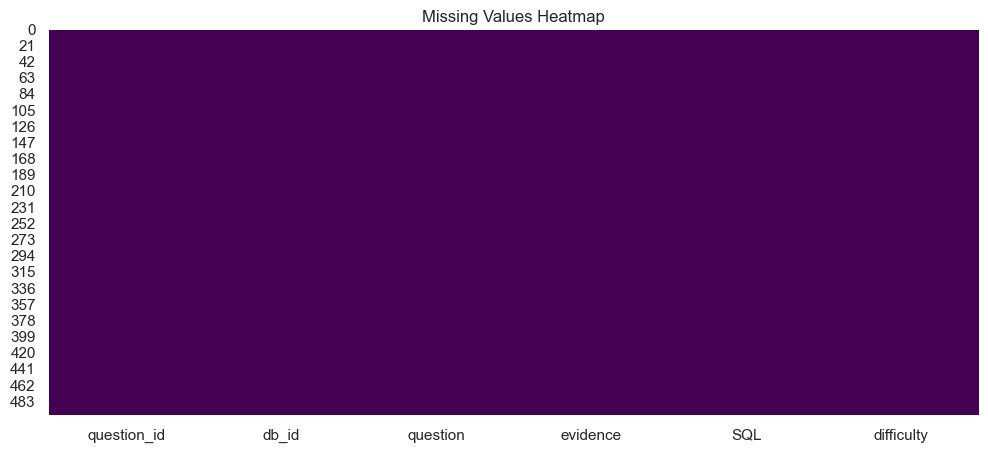

In [38]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [39]:
print("="*60)
print("Empty Fields")
print("="*60)

for column in df.columns:
    
    if df[column].dtype=="object":
        
        empty=(df[column].str.strip()=="").sum()
        
        print(f"{column:15} {empty}")

Empty Fields
db_id           0
question        0
evidence        2
SQL             0
difficulty      0


Duplicate Rows

In [40]:
duplicates=df.duplicated().sum()

print(f"Duplicate rows : {duplicates}")

Duplicate rows : 2


Duplicate Questions

In [41]:
duplicate_questions=df["question"].duplicated().sum()

print(f"Duplicate Questions : {duplicate_questions}")

Duplicate Questions : 2


Duplicate SQL

In [42]:
duplicate_sql=df["SQL"].duplicated().sum()

print(f"Duplicate SQL : {duplicate_sql}")

Duplicate SQL : 2


Duplicate Evidence

In [43]:
duplicate_evidence=df["evidence"].duplicated().sum()

print(f"Duplicate Evidence : {duplicate_evidence}")

Duplicate Evidence : 3


Unique Values

In [46]:
unique_values=pd.DataFrame({
    
    "Unique Values":df.nunique(),
    
    "Data Type":df.dtypes
    
})

unique_values

,Unique Values,Data Type
question_id,498,int64
db_id,11,object
question,498,object
evidence,497,object
SQL,498,object
difficulty,3,object


### Interpretation

The previous analysis provides an initial assessment of the dataset quality.

The absence of missing values and duplicated records indicates that the dataset is well structured and suitable for subsequent preprocessing stages.

The next step consists of exploring the characteristics of each attribute in greater detail.

Distribution des difficultés

In [44]:
difficulty_counts = df["difficulty"].value_counts()

difficulty_counts

difficulty
moderate       250
simple         148
challenging    102
Name: count, dtype: int64

# 6. Exploratory Data Analysis

This section explores the main characteristics of the dataset.

The analysis focuses on:

- Difficulty levels
- Database distribution
- Natural language questions
- Business evidence
- SQL reference queries

The objective is to better understand the data before building the Retrieval-Augmented Generation (RAG) pipeline.

## 6.1 Difficulty Level Analysis

The BIRD dataset categorizes each sample according to its SQL generation complexity.

This analysis helps evaluate the overall complexity of the dataset.

Distribution des difficultés

In [47]:
difficulty_counts = df["difficulty"].value_counts()

difficulty_counts

difficulty
moderate       250
simple         148
challenging    102
Name: count, dtype: int64

In [48]:
difficulty_percentage = (
    df["difficulty"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

difficulty_percentage

difficulty
moderate       50.0
simple         29.6
challenging    20.4
Name: proportion, dtype: float64

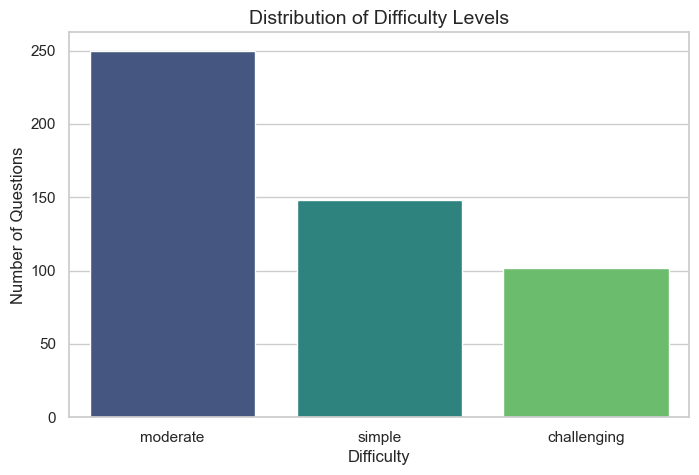

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="difficulty",
    order=difficulty_counts.index,
    palette="viridis"
)

plt.title("Distribution of Difficulty Levels", fontsize=14)

plt.xlabel("Difficulty")

plt.ylabel("Number of Questions")

plt.show()

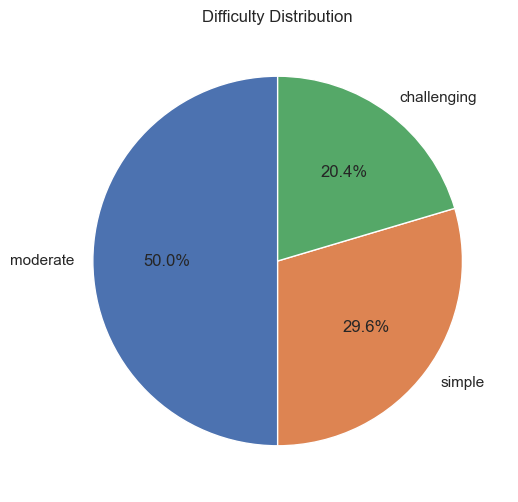

In [51]:
plt.figure(figsize=(6,6))

difficulty_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Difficulty Distribution")

plt.show()

### Interpretation

The distribution of difficulty levels provides insight into the overall complexity of the benchmark.

A balanced dataset enables a more reliable evaluation of retrieval and SQL generation performance.

## 6.2 Database Analysis

Each question belongs to a specific database.

Analyzing database distribution helps determine whether the benchmark is balanced across different domains.

In [52]:
print("Number of databases :", df["db_id"].nunique())

Number of databases : 11


In [53]:
database_counts = df["db_id"].value_counts()

database_counts


db_id
formula_1                  66
superhero                  52
card_games                 52
european_football_2        51
thrombosis_prediction      50
codebase_community         49
student_club               48
toxicology                 40
financial                  32
debit_card_specializing    30
california_schools         30
Name: count, dtype: int64

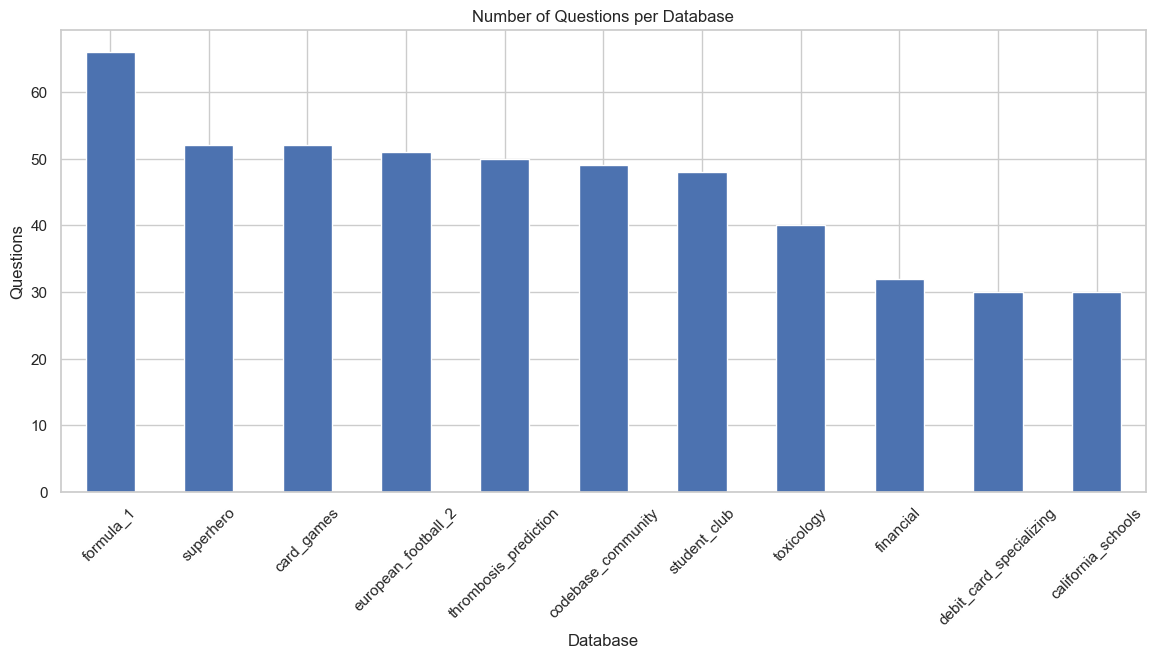

In [54]:
plt.figure(figsize=(14,6))

database_counts.plot(kind="bar")

plt.title("Number of Questions per Database")

plt.xlabel("Database")

plt.ylabel("Questions")

plt.xticks(rotation=45)

plt.show()

In [55]:
database_counts.describe()

count    11.000000
mean     45.454545
std      11.254898
min      30.000000
25%      36.000000
50%      49.000000
75%      51.500000
max      66.000000
Name: count, dtype: float64

### Interpretation

The database distribution reveals whether some databases are overrepresented.

This information is useful for understanding possible biases during retrieval and evaluation.

## 6.3 Natural Language Question Analysis

This section studies the linguistic characteristics of natural language questions.

In [56]:
df["question_length_chars"] = df["question"].str.len()

df["question_length_words"] = df["question"].str.split().str.len()

In [57]:
df[
    [
        "question_length_chars",
        "question_length_words"
    ]
].describe()

,question_length_chars,question_length_words
count,500.000000,500.000000
mean,90.394000,15.824000
std,34.495255,6.127652
min,23.000000,4.000000
25%,66.000000,11.000000
50%,87.000000,15.000000
75%,109.000000,19.000000
max,286.000000,50.000000


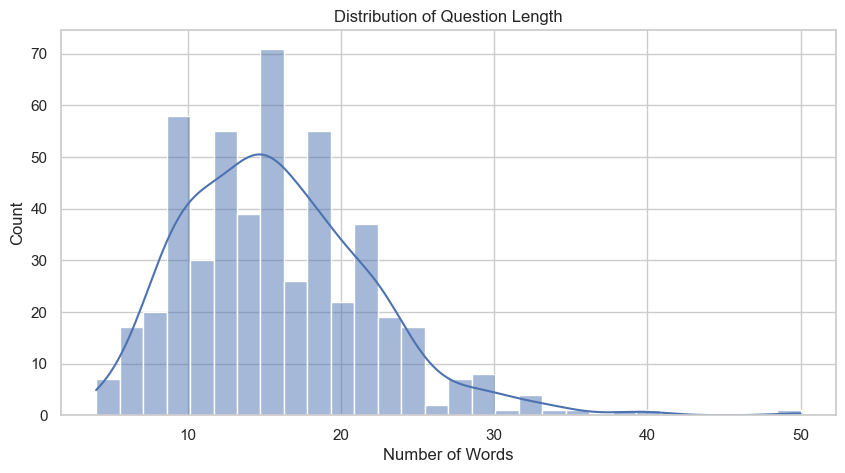

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["question_length_words"],
    bins=30,
    kde=True
)

plt.title("Distribution of Question Length")

plt.xlabel("Number of Words")

plt.show()

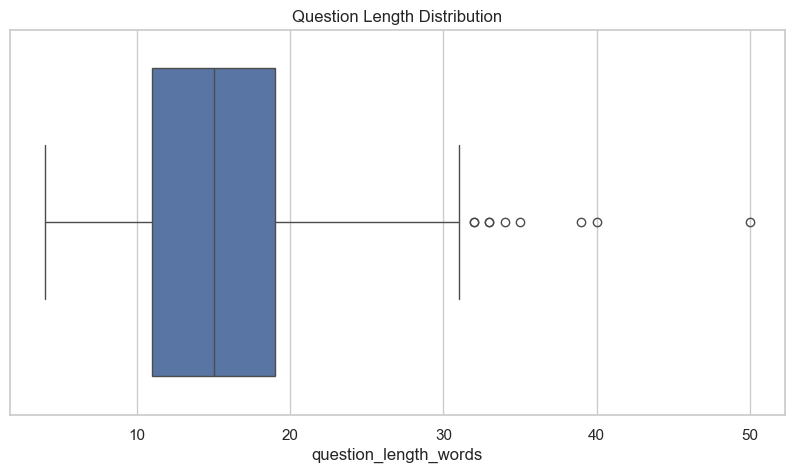

In [59]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["question_length_words"]
)

plt.title("Question Length Distribution")

plt.show()

In [60]:
df.nlargest(
    10,
    "question_length_words"
)[
    [
        "question",
        "db_id"
    ]
]

,question,db_id
465,"Of the schools that offers a magnet program serving a grade span of Kindergarten to 8th grade, how many offers Multiple Provision Types? List the number of cities that offers a Kindergarten to 8th grade span and indicate how many schools are there serving such grade span for each city.",california_schools
467,"What are the valid e-mail addresses of the administrator of the school located in the San Bernardino county, City of San Bernardino City Unified that opened between 1/1/2009 to 12/31/2010 whose school types are public Intermediate/Middle Schools and Unified Schools?",california_schools
446,"What is the average score in writing for the schools that were opened after 1991 or closed before 2000? List the school names along with the score. Also, list the communication number of the schools if there is any.",california_schools
449,What is the eligible free or reduced price meal rate for the top 5 schools in grades 1-12 with the highest free or reduced price meal count of the schools with the ownership code 66?,california_schools
6,"What is the difference in the annual average consumption of the customers with the least amount of consumption paid in CZK for 2013 between SME and LAM, LAM and KAM, and KAM and SME?",debit_card_specializing
259,What is the percentage of superheroes who act in their own self-interest or make decisions based on their own moral code? Indicate how many of the said superheroes were published by Marvel Comics.,superhero
490,"Please list the account types that are not eligible for loans, and the average income of residents in the district where the account is located exceeds $8000 but is no more than $9000.",financial
443,Give the names of the schools with the percent eligible for free meals in K-12 is more than 0.1 and test takers whose test score is greater than or equal to 1500?,california_schools
460,What is the total number of non-chartered schools in the county of Los Angeles with a percent (%) of eligible free meals for grades 1 through 12 that is less than 0.18%?,california_schools
447,"Consider the average difference between K-12 enrollment and 15-17 enrollment of schools that are locally funded, list the names and DOC type of schools which has a difference above this average.",california_schools


In [61]:
df.nsmallest(
    10,
    "question_length_words"
)[
    [
        "question",
        "db_id"
    ]
]

,question,db_id
30,What's Angela Sanders's major?,student_club
255,What is Copycat's race?,superhero
284,What is Abomination's superpower?,superhero
42,What was Brent Thomason's major?,student_club
147,Which player is the tallest?,european_football_2
254,Who is the dumbest superhero?,superhero
285,Which hero was the fastest?,superhero
57,Which event has the lowest cost?,student_club
164,List down most tallest players' name.,european_football_2
252,Which publisher published the slowest superhero?,superhero


### Interpretation

Question length is an important factor for retrieval systems.

Long questions generally contain richer semantic information, while short questions may be more ambiguous.

## 6.4 Business Evidence Analysis

The **evidence** field contains additional business knowledge associated with each natural language question.

Unlike the SQL query, the evidence provides semantic and domain-specific information that can help a Large Language Model better understand the user's intent.

Since the proposed RAG pipeline relies on external knowledge retrieval, understanding the characteristics of this field is essential before constructing the Business Knowledge Base.


In [ ]:
df["evidence_length_chars"] = df["evidence"].str.len()

df["evidence_length_words"] = (
    df["evidence"]
    .str.split()
    .str.len()
)

In [63]:
df[
    [
        "evidence_length_chars",
        "evidence_length_words"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
evidence_length_chars,500.0,124.000,62.590215,0.0,80.75,117.0,159.25,468.0
evidence_length_words,500.0,19.414,9.728715,0.0,12.75,18.0,25.00,77.0


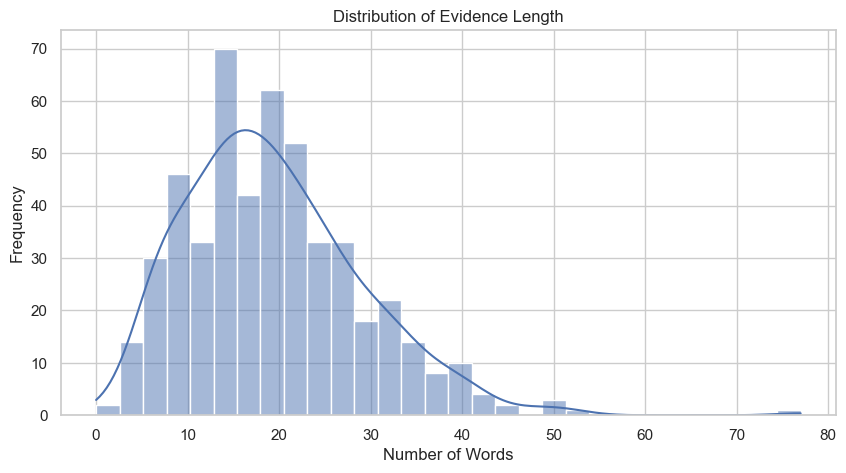

In [64]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="evidence_length_words",
    bins=30,
    kde=True
)

plt.title("Distribution of Evidence Length")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

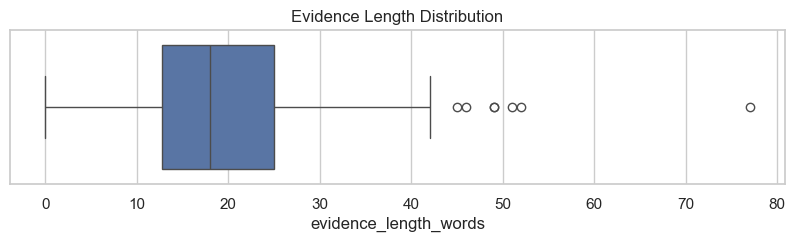

In [65]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["evidence_length_words"]
)

plt.title("Evidence Length Distribution")

plt.show()

Les evidences les plus longues

In [66]:
df.nlargest(
    10,
    "evidence_length_words"
)[
    [
        "db_id",
        "question",
        "evidence"
    ]
]

,db_id,question,evidence
6,debit_card_specializing,"What is the difference in the annual average consumption of the customers with the least amount of consumption paid in CZK for 2013 between SME and LAM, LAM and KAM, and KAM and SME?",annual average consumption of customer with the lowest consumption in each segment = total consumption per year / the number of customer with lowest consumption in each segment; Difference in annual average = SME's annual average - LAM's annual average; Difference in annual average = LAM's annual average - KAM's annual average; Year 2013 can be presented as Between 201301 And 201312; The first 4 strings of the Date values in the yearmonth table can represent year.
9,debit_card_specializing,"How many more ""discount"" gas stations does the Czech Republic have compared to Slovakia?","Czech Republic can be represented as the Country value in gasstations table is 'CZE'; Slovakia can be represented as the Country value in the gasstations table is 'SVK'; Computation of more ""discount"" gas stations= Total no. of discount gas stations in Czech Republic - Total no. of discount gas stations in Slovakia"
481,financial,"For loans contracts which are still running where client are in debt, list the district of the and the state the percentage unemployment rate increment from year 1995 to 1996.",Unemployment increment rate in percentage = [(unemployment rate 2016 - unemployment rate 2015) / unemployment rate 2015] * 100; unemployment rate 2015 appears in the A12; unemployment rate 2016 appears in the A13; Loan contracts which are still running where client are in debt can be presented as status = 'D'
89,thrombosis_prediction,What is the ratio of male to female patients among all those with abnormal uric acid counts?,"male refers to SEX = 'M'; female refers to SEX = 'F'; abnormal uric acid refers to UA < = '8.0' where SEX = 'M', UA < = '6.5' where SEX = 'F'; calculation = DIVIDE(SUM(UA <= '8.0' and SEX = 'M'), SUM(UA <= '6.5 and SEX = 'F'))"
145,european_football_2,What is the difference of the average ball control score between Abdou Diallo and Aaron Appindangoye\n?,"difference of the average ball control = SUBTRACT(AVG(ball_control WHERE player_name = 'Abdou Diallo'), AVG(ball_control WHERE player_name = 'Aaron Appindangoye')); AVG(ball_control WHERE player_name = 'XX XX') = SUM(CASE WHEN player_name = 'XX XX' THEN ball_control ELSE 0 END) / COUNT(CASE WHEN player_name = 'XX XX' THEN id ELSE NULL END)"
129,european_football_2,"In Scotland Premier League, which away team won the most during the 2010 season?","Final result should return the Team.team_long_name; Scotland Premier League refers to League.name = 'Scotland Premier League'; away team refers to away_team_api_id; away team that won the most refers to MAX(SUBTRACT(away_team_goal, home_team_goal) > 0); 2010 season refers to season = '2009/2010'; won the most refers to MAX(COUNT(*));"
195,formula_1,"Paul di Resta was in the No. 853 race, what percent faster did he finish in the 853rd race than the next race for the fastest lap speed?","Paul di Resta refers to the full name of the driver; Full name of the driver refers to drivers.forename ='Paul' and drivers.surname = 'di Resta'; race number refers to raceId; percentage = DIVIDE(SUBTRACT(fastestLapSpeed(raceId = 853), (fastestLapSpeed (raceId = 854)) * 100 , (fastestLapSpeed(raceId = 853))"
37,student_club,Calculate the total average cost that Elijah Allen spent in the events on September and October.,"Elijah Allen is the full name; full name refers to first_name, last_name; The 5th and 6th string of the expense_date in the expense table can refer to month; events in September and October refers to month(expense_date) = 9 OR month(expense_date) = 10"
112,thrombosis_prediction,"For patients with abnormal platelet level, state the number of patients with lower than normal range. How is it compare to the number of patients with higher than normal range?","abnormal platelet level refers to PLT <= 100 or PLT

Les plus courtes

In [67]:
df.nsmallest(
    10,
    "evidence_length_words"
)[
    [
        "db_id",
        "question",
        "evidence"
    ]
]

,db_id,question,evidence
18,debit_card_specializing,Please list the disparate time of the transactions taken place in the gas stations from chain no. 11.,
26,debit_card_specializing,"What is the percentage of ""premium"" against the overall segment in Country = ""SVK""?",
229,formula_1,List out the code for drivers who have nationality in American.,nationality = 'American'
255,superhero,What is Copycat's race?,Copycat is the superhero_name;
49,student_club,"What does the person with the phone number ""809-555-3360"" major in?",major in refers to major_name
60,student_club,How many members of the Student_Club have major in 'Physics Teaching'?,'Physics Teaching' is the major_name;
71,student_club,List the last name of members with a major in environmental engineering and include its department and college name.,'Environmental Engineering' is the major_name;
147,european_football_2,Which player is the tallest?,tallest player refers to MAX(height);
261,superhero,Give the publisher ID of Star Trek.,Star Trek is the publisher_name;
283,superhero,Calculate the average height for all superhero.,"average = DIVIDE(SUM(height_cm), COUNT(all heros));"


Evidence vides

In [68]:
empty_evidence = (
    df["evidence"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"Empty evidence: {empty_evidence}")

Empty evidence: 2


Evidences dupliquées

In [69]:
duplicated_evidence = (
    df["evidence"]
    .duplicated()
    .sum()
)

print(f"Duplicated evidence: {duplicated_evidence}")

Duplicated evidence: 3


In [70]:
unique_evidence = df["evidence"].nunique()

print(f"Unique evidence: {unique_evidence}")

Unique evidence: 497


Les evidences les plus fréquentes

In [71]:
df["evidence"].value_counts().head(10)

evidence
                                                                                                                                                                                                              2
Status = 'C' stands for running contract, OK so far; Status = 'D' stands for running contract, client in debt                                                                                                 2
Male refers to gender = 'M'; A15 stands for no. of commited crimes 1995                                                                                                                                       2
Intermediate/Middle Schools refers to SOC = 62; Unified School refers to DOC = 54; years between 2009 and 2010 can refer to 'between 1/1/2009 to 12/31/2010'                                                  1
A3 contains the data of region; 'POPLATEK PO OBRATU' represents for 'issuance after transaction'.                                                              

Distribution par difficulté

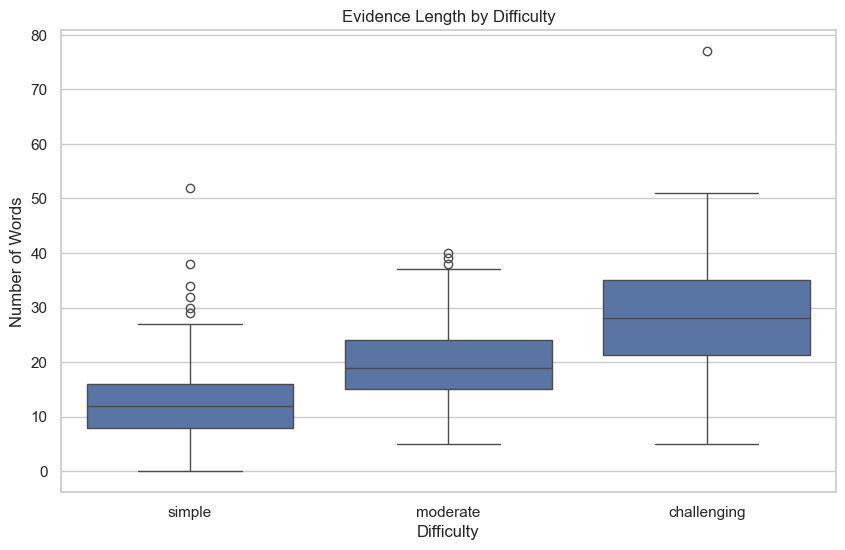

In [72]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="difficulty",
    y="evidence_length_words"
)

plt.title("Evidence Length by Difficulty")

plt.xlabel("Difficulty")

plt.ylabel("Number of Words")

plt.show()

In [73]:
average_evidence = (
    df.groupby("db_id")["evidence_length_words"]
      .mean()
      .sort_values(ascending=False)
)

average_evidence.head(15)

db_id
thrombosis_prediction      26.220000
debit_card_specializing    23.133333
card_games                 21.211538
european_football_2        20.705882
formula_1                  20.439394
financial                  18.875000
superhero                  18.634615
toxicology                 16.650000
student_club               15.562500
codebase_community         15.408163
california_schools         15.100000
Name: evidence_length_words, dtype: float64

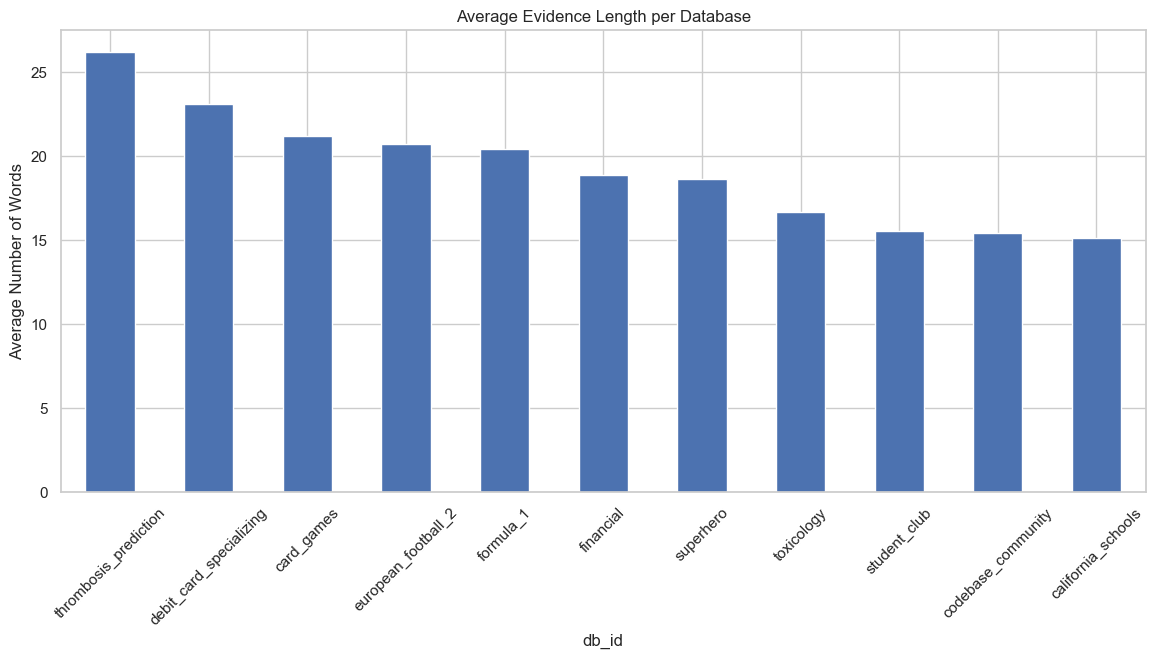

In [74]:
plt.figure(figsize=(14,6))

average_evidence.plot(kind="bar")

plt.title("Average Evidence Length per Database")

plt.ylabel("Average Number of Words")

plt.xticks(rotation=45)

plt.show()

WordCloud

In [78]:
text = " ".join(df["evidence"].fillna(""))
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

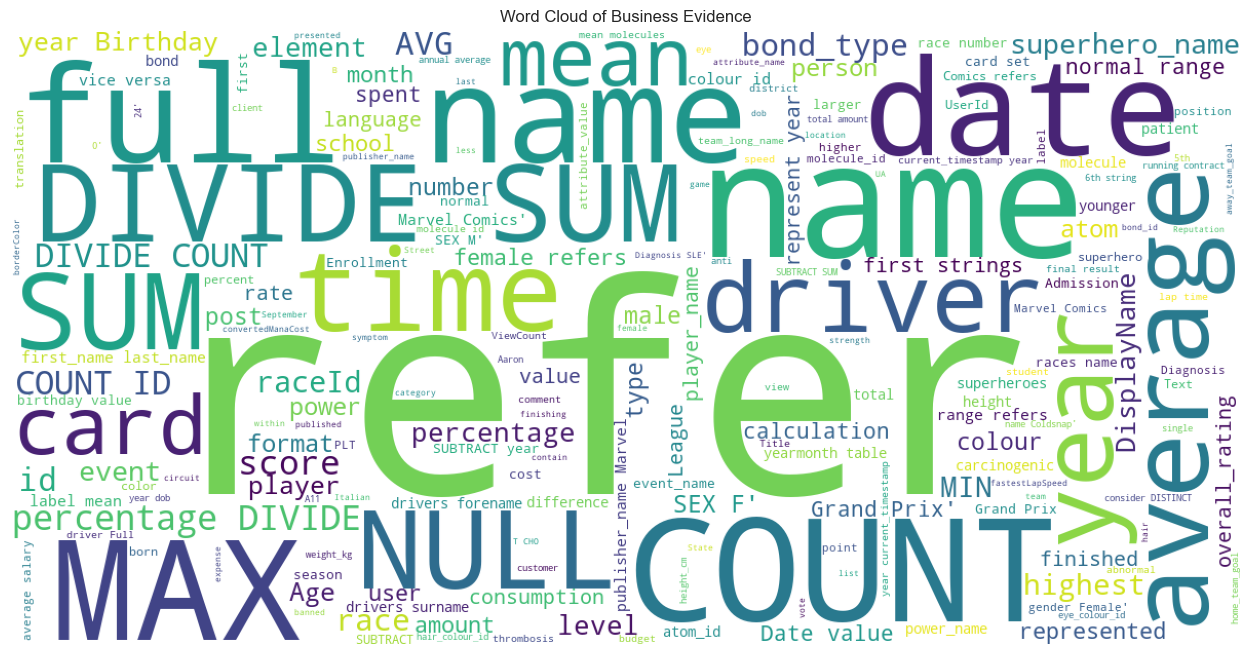

In [79]:
plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Business Evidence")

plt.show()

Les mots les plus fréquents

In [80]:
import re
from collections import Counter

words = re.findall(r"\b[a-zA-Z_]+\b", text.lower())

counter = Counter(words)

pd.DataFrame(
    counter.most_common(30),
    columns=["Word","Frequency"]
)

,Word,Frequency
0,to,756
1,refers,712
2,the,363
3,of,199
4,and,142
5,name,142
6,is,133
7,count,123
8,in,119
9,where,98


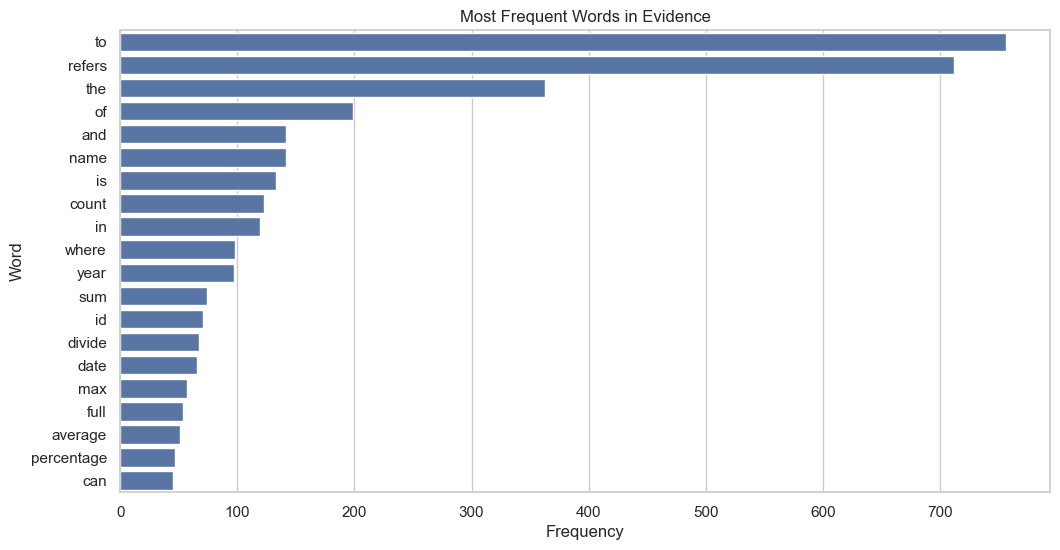

In [81]:
top_words = pd.DataFrame(
    counter.most_common(20),
    columns=["Word","Frequency"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("Most Frequent Words in Evidence")

plt.show()

### Interpretation

The analysis of the **evidence** field shows its richness in business terminology and domain-specific concepts.

Several observations can be drawn:

- The evidence generally contains concise business rules.
- The average evidence length suggests that the retrieved context will remain compact, which is beneficial for Large Language Models.
- Duplicate evidence indicates that similar business knowledge may support multiple questions.
- The Word Cloud highlights the most common business concepts appearing throughout the dataset.

Overall, the evidence field constitutes a valuable source of external knowledge and will serve as the foundation for constructing the **Business Knowledge Base** used by the Retrieval-Augmented Generation (RAG) system.